In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

In [2]:
df = pd.read_csv('ecommerce_estatistica_V1.csv')

In [3]:
df.head()

,produto,marca,material,preco,desconto,preco_desconto,publico_voltado,nota,avaliacoes,qtd_vendidos,sazonalidade
0,Kit 10 Cuecas Boxer Lupo Cueca Box Algodão Mas...,lupo,algodão,232.89,18,190.97,Masculino,4.5,3034,10000,6 meses menor temperatura
1,Kit Com 10 Cuecas Boxer Algodão Sem Costura Zo...,zorba,algodão,199.90,20,159.92,Masculino,4.7,5682,50000,demanda regular
2,Kit 10 Cuecas Boxer Mash Algodão Cotton Box Or...,mash,algodão,229.39,22,178.92,Masculino,4.6,1700,10000,6 meses maior temperatura
3,Kit 3 Short Jeans Feminino Cintura Alta Barato...,menina linda,jean,129.20,9,117.57,Feminino,4.4,507,1000,6 meses maior temperatura
4,Blusa + Calça Térmica Treino Futebol Criança I...,roupa zero grau,termico unissex,78.03,5,74.13,infantil:Unissex,4.7,58,100,6 meses menor temperatura


In [4]:
media = np.round(np.mean(df['preco']), 2)
media

np.float64(129.47)

In [5]:
mediana = np.round(np.median(df['preco']), 2)
mediana

np.float64(129.2)

In [6]:
desvio = np.round(np.std(df['preco']), 2)
desvio

np.float64(64.48)

In [7]:
quartis = [np.quantile(df['preco'], 0.25), np.quantile(df['preco'], 0.5), round(np.quantile(df['preco'], 0.75), 2)]
quartis

[np.float64(72.88), np.float64(129.2), np.float64(175.98)]

In [8]:
IQR = quartis[2] - quartis[0]
IQR

np.float64(103.1)

In [9]:
IA = [quartis[0] - (1.5 * IQR), quartis[2] + (1.5*IQR)]
IA

[np.float64(-81.76999999999998), np.float64(330.63)]

In [10]:
gb = round(((quartis[2] - quartis[1]) - (quartis[1] - quartis[0])) / (IQR), 2)
gb

np.float64(-0.09)

In [11]:
df['preco'].min()

np.float64(25.63)

In [12]:
df['preco'].max()

np.float64(326.55)

In [30]:
sns.set_palette('Purples_r')

Text(0, 0.5, 'Grau de Densidade')

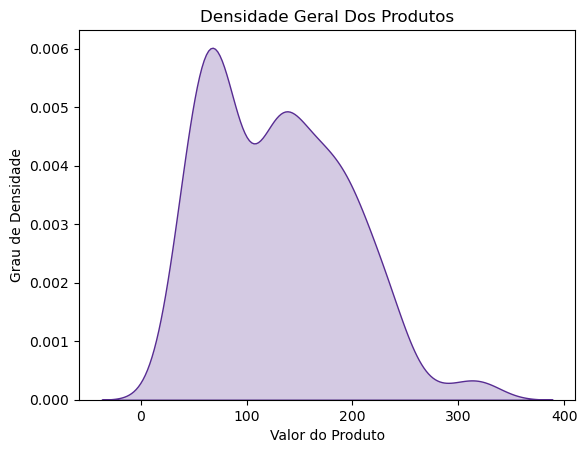

In [31]:
sns.kdeplot(x='preco', data=df, fill=True)
plt.title('Densidade Geral Dos Produtos')
plt.xlabel('Valor do Produto')
plt.ylabel('Grau de Densidade')

Text(0.5, 1.0, 'Histograma para Densidade Geral dos Produtos')

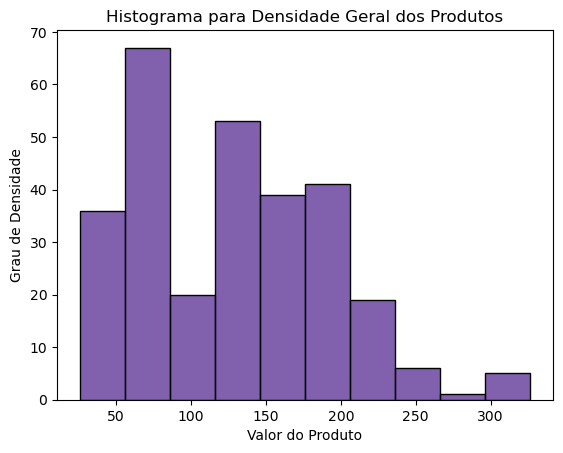

In [32]:
sns.histplot(x='preco', data=df, stat="count")
plt.xlabel('Valor do Produto')
plt.ylabel('Grau de Densidade')
plt.title('Histograma para Densidade Geral dos Produtos')

Text(0.5, 0, 'Preço')

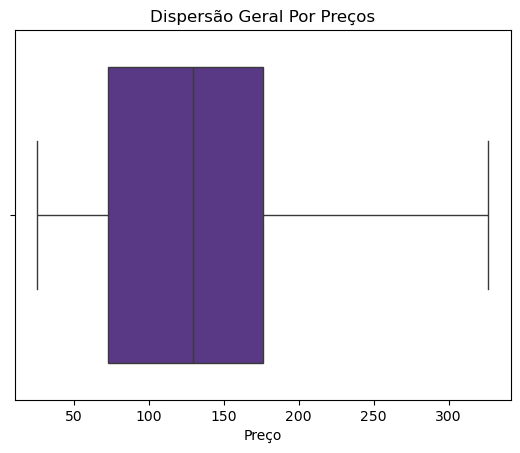

In [33]:
sns.boxplot(x='preco', data=df)
plt.title('Dispersão Geral Por Preços')
plt.xlabel('Preço')

In [16]:
df['preco'].value_counts().head(3)

preco
203.88    9
129.20    6
89.90     6
Name: count, dtype: int64

In [17]:
top_3_produto = ["Macacão Roupa De Apicultor Completa Proteção Contra Abelhas", 
                 "Kit 3 Short Jeans Feminino Cintura Alta Barato Atacado",
                 "Kit 4 Cuecas Boxer Lupo Em Algodão Masculina Cotton Original"] 
top_3_preco = [203.88, 129.20, 89.90]

Text(0.5, 0, 'Valor')

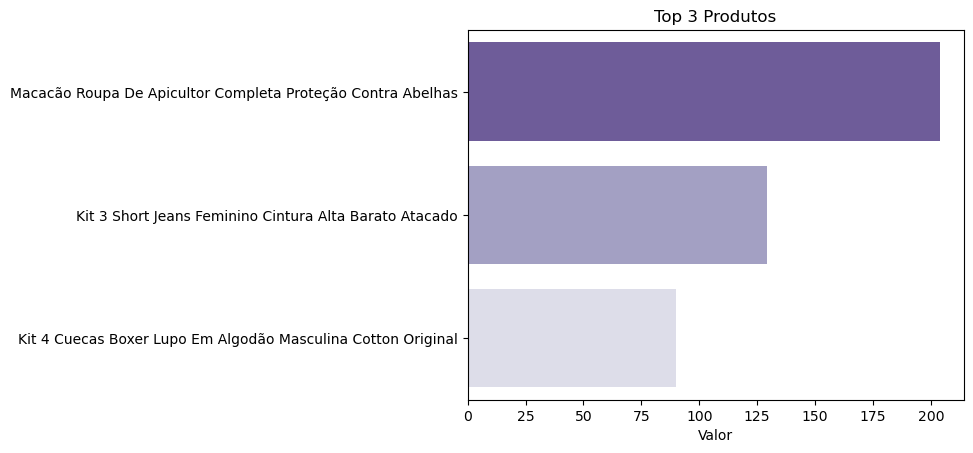

In [50]:
sns.barplot(x=top_3_preco, y=top_3_produto, hue=top_3_produto,
            palette="Purples_r")
plt.title("Top 3 Produtos")
plt.xlabel("Valor")

In [19]:
df.value_counts(subset=['produto', 'marca', 'preco', 'qtd_vendidos', 'publico_voltado']).head(3)

produto                                                       marca         preco   qtd_vendidos  publico_voltado
Macacão Roupa De Apicultor Completa Proteção Contra Abelhas   celi          203.88  1000          Unissex            9
Kit 3 Short Jeans Feminino Cintura Alta Barato Atacado        menina linda  129.20  1000          Feminino           6
Kit 4 Cuecas Boxer Lupo Em Algodão Masculina Cotton Original  lupo          89.90   10000         Masculino          6
Name: count, dtype: int64

Text(0.5, 1.0, 'Proporção das 3 maiores marcas')

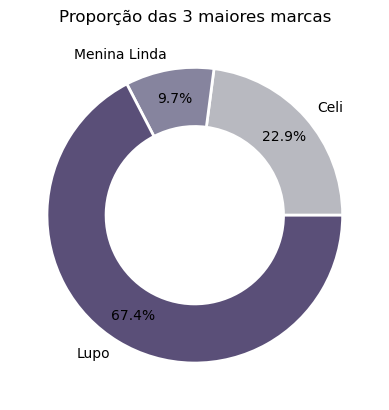

In [49]:
eixo_x = [1834920, 775200, 5394000]
marca = ['Celi', 'Menina Linda', 'Lupo']
paleta = ["#B8B9C0", "#86849E", "#5A4F78"]
plt.pie(eixo_x, labels=marca, colors=paleta, autopct='%1.1f%%', 
        pctdistance=0.80, wedgeprops={'width': 0.4, 'edgecolor': 'w', 'linewidth': 2})
plt.title('Proporção das 3 maiores marcas')

In [21]:
df.value_counts(subset=['marca', 'publico_voltado']).head(3)

marca           publico_voltado
lupo            Masculino          31
stillger jeans  Feminino           16
celi            Unissex            15
Name: count, dtype: int64

In [22]:
top3_marcas = ['lupo:masculino', 'stillger jeans:Feminino', 'celi:Unissex']
top3_marcas_vl = [31, 16, 15]

Text(0.5, 0, 'Proporção de aparições da marca')

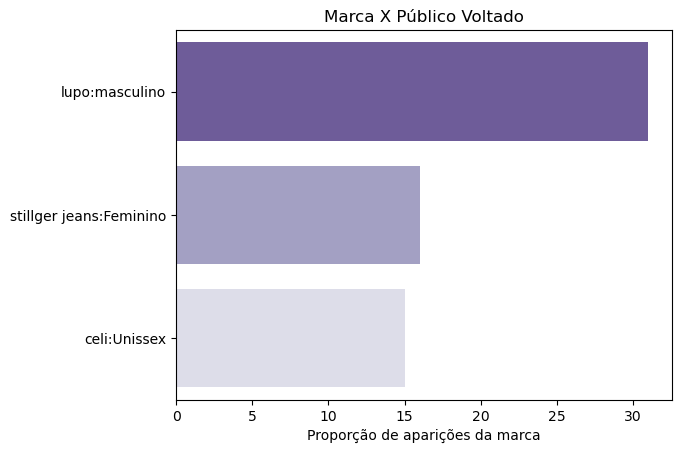

In [48]:
sns.barplot(x=top3_marcas_vl, y=top3_marcas, hue=top3_marcas, palette="Purples_r")
plt.title("Marca X Público Voltado")
plt.xlabel('Proporção de aparições da marca')

In [47]:
resultado = df.groupby(['produto', 'sazonalidade'])['preco_desconto'].agg(['count', 'mean', 'min', 'max']).head(35).round(2)
resultado.to_markdown()

"|                                                                                               |   count |   mean |    min |    max |\n|:----------------------------------------------------------------------------------------------|--------:|-------:|-------:|-------:|\n| ('10 Shorts Ginástica Moda Fitness Roupas Femininas Atacado', '6 meses maior temperatura')    |       2 | 190.8  | 190.8  | 190.8  |\n| ('2 Conjuntos Ciclista Liso + Top Roupas Femininas Academia', '6 meses maior temperatura')    |       1 |  68.49 |  68.49 |  68.49 |\n| ('2 Shorts Iguais Casal Praia 5 Estampas Roupa Combinando', '6 meses maior temperatura')      |       1 | 128.61 | 128.61 | 128.61 |\n| ('3 Conjuntos Fitness Feminino Top + Short Roupas Academia A11', '6 meses maior temperatura') |       1 | 104.66 | 104.66 | 104.66 |\n| ('4 Short Bermuda Masculina Esporte Dry Fit Academia Plus', '6 meses maior temperatura')      |       1 | 134.92 | 134.92 | 134.92 |\n| ('5 Bermudas Fitness Feminina Tapa Bumbum Rou

In [25]:
df.value_counts(subset=['produto', 'sazonalidade'])

produto                                                       sazonalidade             
Macacão Roupa De Apicultor Completa Proteção Contra Abelhas   demanda regular              9
Kit 3 Short Jeans Feminino Cintura Alta Barato Atacado        6 meses maior temperatura    6
Kit 4 Cuecas Boxer Lupo Em Algodão Masculina Cotton Original  6 meses maior temperatura    6
Kit 2 Cuecas Boxer Lupo Basic Microfibra Sem Costura Box      6 meses maior temperatura    6
Macacão Apicultor Roupa Proteção Abelha Com Máscara + Brinde  demanda regular              6
                                                                                          ..
Calça Jeans Infantil Juvenil Masculina C/ Elastano Mzocokids  6 meses menor temperatura    1
Calça Linho Mom Feminina Bege Sawary                          6 meses menor temperatura    1
Bermuda Infantil Jeans Masculino Roupa Short Menino           6 meses maior temperatura    1
Kit 3 Cuecas Low Rise Trunk Calvin Klein                      6 meses menor

In [26]:
df[df['produto'] == "Macacão Apicultor Roupa Proteção Abelha Com Máscara + Brinde"]

,produto,marca,material,preco,desconto,preco_desconto,publico_voltado,nota,avaliacoes,qtd_vendidos,sazonalidade
11,Macacão Apicultor Roupa Proteção Abelha Com Má...,celi,algodão,166.21,10,149.59,Unissex,4.1,331,1000,demanda regular
87,Macacão Apicultor Roupa Proteção Abelha Com Má...,celi,algodão,166.21,10,149.59,Unissex,4.1,331,1000,demanda regular
92,Macacão Apicultor Roupa Proteção Abelha Com Má...,celi,algodão,166.21,10,149.59,Unissex,4.1,331,1000,demanda regular
146,Macacão Apicultor Roupa Proteção Abelha Com Má...,celi,algodão,166.21,10,149.59,Unissex,4.1,332,1000,demanda regular
200,Macacão Apicultor Roupa Proteção Abelha Com Má...,celi,algodão,166.21,10,149.59,Unissex,4.1,332,1000,demanda regular
260,Macacão Apicultor Roupa Proteção Abelha Com Má...,celi,algodão,166.21,10,149.59,Unissex,4.1,332,1000,demanda regular


In [27]:
df[df['produto'] == "Macacão Roupa De Apicultor Completa Proteção Contra Abelhas"]

,produto,marca,material,preco,desconto,preco_desconto,publico_voltado,nota,avaliacoes,qtd_vendidos,sazonalidade
10,Macacão Roupa De Apicultor Completa Proteção C...,celi,brim 100% algodão,203.88,24,154.95,Unissex,4.3,178,1000,demanda regular
69,Macacão Roupa De Apicultor Completa Proteção C...,celi,brim 100% algodão,203.88,24,154.95,Unissex,4.3,178,1000,demanda regular
78,Macacão Roupa De Apicultor Completa Proteção C...,celi,brim 100% algodão,203.88,24,154.95,Unissex,4.3,178,1000,demanda regular
134,Macacão Roupa De Apicultor Completa Proteção C...,celi,brim 100% algodão,203.88,24,154.95,Unissex,4.3,178,1000,demanda regular
137,Macacão Roupa De Apicultor Completa Proteção C...,celi,brim 100% algodão,203.88,24,154.95,Unissex,4.3,178,1000,demanda regular
186,Macacão Roupa De Apicultor Completa Proteção C...,celi,brim 100% algodão,203.88,24,154.95,Unissex,4.3,178,1000,demanda regular
191,Macacão Roupa De Apicultor Completa Proteção C...,celi,brim 100% algodão,203.88,24,154.95,Unissex,4.3,178,1000,demanda regular
246,Macacão Roupa De Apicultor Completa Proteção C...,celi,brim 100% algodão,203.88,24,154.95,Unissex,4.3,178,1000,demanda regular
249,Macacão Roupa De Apicultor Completa Proteção C...,celi,brim 100% algodão,203.88,24,154.95,Unissex,4.3,178,1000,demanda regular
